## Lec 6. 编码器-解码器结构

- Encoder-Decoder
    - VAE `变分自编码器` Variational Auto-Encoder
    - Seq2Seq `序列到序列`
    - Transformer

### 6.1 Model 持久化

- model.state_dict()
- pickle 序列化

In [14]:
import torch.nn as nn
import torch

# 创建一个 Module 并进行训练
model = nn.Linear(10, 20)
model

Linear(in_features=10, out_features=20, bias=True)

In [15]:
# 保存该 Module 的所有参数为二进制数据到本地硬盘
torch.save(model.state_dict(), "model.pt")

In [8]:
# 重新创建一个新的随机参数的同结构的Module实例
model2 = nn.Linear(10, 20)

# 从硬盘中载入之前保存的参数二进制数据，并更新到 model2上
model2.load_state_dict(torch.load("model.pt"))
model2.state_dict()

OrderedDict([('weight',
              tensor([[-0.0534, -0.2778, -0.1821, -0.0034,  0.2864, -0.0079,  0.1855, -0.0347,
                        0.0617,  0.1628],
                      [ 0.2476,  0.0827, -0.1634, -0.2759,  0.1044,  0.2797,  0.2222,  0.1854,
                        0.1729,  0.1246],
                      [-0.1752, -0.1504, -0.2989,  0.1888, -0.0262, -0.3110,  0.2522, -0.2286,
                        0.1189,  0.0940],
                      [ 0.0082,  0.2095,  0.0134, -0.0441, -0.2828,  0.2225,  0.2453, -0.2812,
                       -0.1183,  0.2229],
                      [-0.0246,  0.2798,  0.0441,  0.1340,  0.0207, -0.2411, -0.0015, -0.1729,
                       -0.0033,  0.2511],
                      [ 0.0206, -0.1922, -0.1024,  0.1541, -0.1385,  0.0709,  0.2011,  0.0352,
                        0.1491, -0.0337],
                      [ 0.2551,  0.2353,  0.1330,  0.2927, -0.1121, -0.2193, -0.1685,  0.0506,
                       -0.3027,  0.2144],
                 

In [23]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [24]:
with open("model.pkl", "rb") as f:
    model2 = pickle.load(f)

In [26]:
model2.state_dict()

OrderedDict([('weight',
              tensor([[-5.9482e-02, -8.3157e-02, -7.6030e-02, -2.2467e-01,  2.8664e-01,
                       -1.5657e-01,  1.4247e-01,  2.8081e-02,  3.1169e-01,  1.2539e-01],
                      [-2.0187e-01,  1.8794e-01, -2.8247e-01, -1.6998e-01, -1.9296e-01,
                        9.4516e-02, -2.8020e-01, -3.1552e-01, -1.1252e-01, -2.9674e-01],
                      [-1.1605e-01, -8.5360e-02,  5.5917e-02, -2.7712e-01,  3.0731e-01,
                        1.3877e-01, -9.6481e-02,  2.7813e-01, -2.5448e-01,  9.2695e-02],
                      [ 8.1853e-03,  1.6983e-01,  2.4951e-01,  2.9415e-01, -7.7570e-02,
                       -1.0114e-01,  1.3828e-01,  2.5150e-02,  6.2707e-02,  1.8840e-01],
                      [-2.3027e-01,  2.2718e-01, -1.8090e-01,  5.1892e-02,  4.4392e-02,
                       -1.5303e-01, -2.1944e-01, -1.2711e-04,  5.4413e-02, -6.2314e-02],
                      [ 4.1360e-02, -3.0252e-01,  1.5029e-01,  2.2699e-02, -1.4924e-01,
   

In [27]:
model.state_dict()

OrderedDict([('weight',
              tensor([[-5.9482e-02, -8.3157e-02, -7.6030e-02, -2.2467e-01,  2.8664e-01,
                       -1.5657e-01,  1.4247e-01,  2.8081e-02,  3.1169e-01,  1.2539e-01],
                      [-2.0187e-01,  1.8794e-01, -2.8247e-01, -1.6998e-01, -1.9296e-01,
                        9.4516e-02, -2.8020e-01, -3.1552e-01, -1.1252e-01, -2.9674e-01],
                      [-1.1605e-01, -8.5360e-02,  5.5917e-02, -2.7712e-01,  3.0731e-01,
                        1.3877e-01, -9.6481e-02,  2.7813e-01, -2.5448e-01,  9.2695e-02],
                      [ 8.1853e-03,  1.6983e-01,  2.4951e-01,  2.9415e-01, -7.7570e-02,
                       -1.0114e-01,  1.3828e-01,  2.5150e-02,  6.2707e-02,  1.8840e-01],
                      [-2.3027e-01,  2.2718e-01, -1.8090e-01,  5.1892e-02,  4.4392e-02,
                       -1.5303e-01, -2.1944e-01, -1.2711e-04,  5.4413e-02, -6.2314e-02],
                      [ 4.1360e-02, -3.0252e-01,  1.5029e-01,  2.2699e-02, -1.4924e-01,
   

### 6.2 VAE (Variational Auto-Encoder)

- VAE 使用场景
    - 图像生成, 文本生成, 音频生成....
    - 数据增强
    - ......

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [36]:
class VAE(nn.Module):
    """ 变分自编码器 """
    def __init__(self, input_size=784, hidden_size=256, latent_size=32):
        super().__init__()
        # Encoder 编码器
        self.encoder = nn.Sequential(nn.Linear(input_size, hidden_size), 
                                     nn.ReLU(), 
                                     nn.Linear(hidden_size, hidden_size//2), 
                                     nn.ReLU())
        
        # 计算 Latent Space的均值和对数方差
        self.fc_mu = nn.Linear(hidden_size//2, latent_size)
        self.fc_logvar = nn.Linear(hidden_size//2, latent_size)
        
        # Decoder 解码器
        self.decoder = nn.Sequential(nn.Linear(latent_size, hidden_size//2), 
                                     nn.ReLU(), 
                                     nn.Linear(hidden_size//2, hidden_size), 
                                     nn.ReLU(), 
                                     nn.Linear(hidden_size, input_size), 
                                     nn.Sigmoid())   # 将输出压缩在 (0, 1) 的范围内
        
    def reparameterize(self, mu, logvar):
        """ 重参数化方法 """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        """ 前向传播方法 """
        # Encoding 编码过程
        hidden = self.encoder(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)

        # Reparameterize 重参数化过程
        z = self.reparameterize(mu, logvar)

        # Decoding 解码过程
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

In [39]:
model = VAE()
x_recon, mu, logvar = model(torch.rand(16, 784))
x_recon.shape, mu.shape, logvar.shape

(torch.Size([16, 784]), torch.Size([16, 32]), torch.Size([16, 32]))

#### 1. 数据集

In [50]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

trans = transforms.Compose([transforms.ToTensor()])

dataset = torchvision.datasets.FashionMNIST(root="../data", train=False, transform=trans, download=True)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

#### 2. 损失函数

In [42]:
def vae_loss(x_recon, x, mu, logvar):
    """ 自定义损失函数, 用于描述重建损失 Loss = 重构损失 + KL散度 """
    # 重构损失
    BCE = F.binary_cross_entropy(x_recon, x.view(-1, 784), reduction="sum")
    
    # KL散度
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

#### 3. 构建模型

In [68]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cpu')

In [69]:
model = VAE().to(device)
loss_func = vae_loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#### 4. 训练模型

In [70]:
def train_model(model, dataloader, loss_func, optimizer):
    """ 模型训练函数 """
    model.train()
    total_loss = 0
    for x, _ in dataloader:
        x_recon, mu, logvar = model(x.to(device).view(-1, 784))
        loss = loss_func(x_recon, x, mu, logvar)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(dataloader)

In [71]:
n_epoch = 200

train_loss = []
for i in range(n_epoch):
    loss = train_model(model, dataloader, loss_func, optimizer)
    train_loss.append(loss)
    print(f"Epoch {i+1} loss: {round(loss, 4)}")

Epoch 1 loss: 106371.1494
Epoch 2 loss: 85571.442
Epoch 3 loss: 77422.1201
Epoch 4 loss: 74777.8836
Epoch 5 loss: 72922.207
Epoch 6 loss: 71182.9163
Epoch 7 loss: 70034.7729
Epoch 8 loss: 69029.4855
Epoch 9 loss: 68110.4302
Epoch 10 loss: 67406.2653
Epoch 11 loss: 66835.8584
Epoch 12 loss: 66401.5835
Epoch 13 loss: 66026.0545
Epoch 14 loss: 65682.8547
Epoch 15 loss: 65330.3367
Epoch 16 loss: 65106.0032
Epoch 17 loss: 64819.6506
Epoch 18 loss: 64594.653
Epoch 19 loss: 64435.1588
Epoch 20 loss: 64291.6506
Epoch 21 loss: 64036.7611
Epoch 22 loss: 63916.4356
Epoch 23 loss: 63730.9875
Epoch 24 loss: 63564.5766
Epoch 25 loss: 63471.0489
Epoch 26 loss: 63358.2051
Epoch 27 loss: 63168.5694
Epoch 28 loss: 63123.7795
Epoch 29 loss: 62989.9403
Epoch 30 loss: 62888.7783
Epoch 31 loss: 62842.9288
Epoch 32 loss: 62760.5156
Epoch 33 loss: 62650.7954
Epoch 34 loss: 62579.8853
Epoch 35 loss: 62494.4144
Epoch 36 loss: 62421.9436
Epoch 37 loss: 62420.8736
Epoch 38 loss: 62370.579
Epoch 39 loss: 62270.193

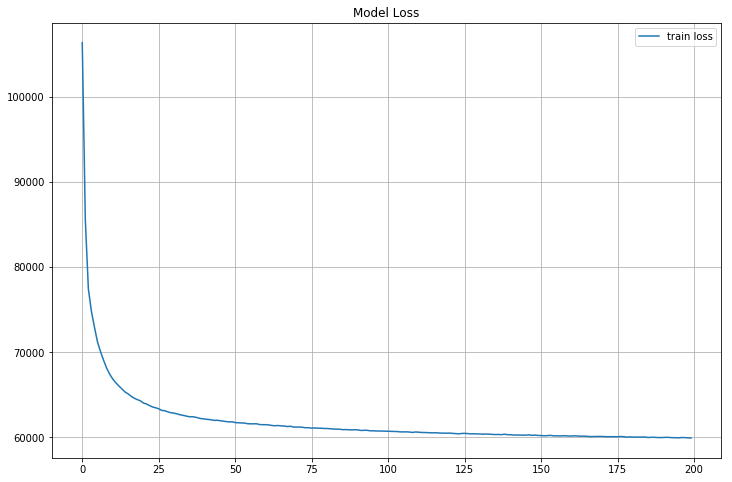

In [72]:
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

plt.figure(figsize=(12, 8))
plt.plot(train_loss, label="train loss")
plt.title("Model Loss")
plt.grid()
plt.legend()
plt.show()

In [73]:
# 使用 VAE 数据增强
with torch.no_grad():
    # 从标准正态分布中采样 Latent 潜层特征
    z = torch.randn(16, 32).to(device) 
    # 通过 VAE-Decoder 将采样得到的 潜层特征 z 生成样本数据 (28x28的图像数据)
    generated_samples = model.decoder(z).view(-1, 1, 28, 28).cpu()
    
generated_samples.shape

torch.Size([16, 1, 28, 28])

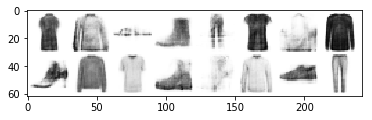

In [74]:
plt.imshow(torchvision.utils.make_grid(generated_samples)[0], cmap="Greys")